# 📍 LOF (Local Outlier Factor) — Anomaly Detection

## 🎯 Objective
Detect anomalies using **Local Density-based approach**

👉 Points with lower density than neighbors are anomalies

In [1]:
# Import libraries

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.neighbors import LocalOutlierFactor
from sklearn.datasets import make_blobs

## 📊 Step 1: Create Dataset

- Normal clustered data  
- Add some random outliers  

In [2]:
# Generate normal data

X, _ = make_blobs(n_samples=300, centers=1, cluster_std=1.0, random_state=42)

# Add outliers
outliers = np.random.uniform(low=-6, high=6, size=(20, 2))

# Combine data
X = np.vstack([X, outliers])

## 📊 Step 2: Visualize Data

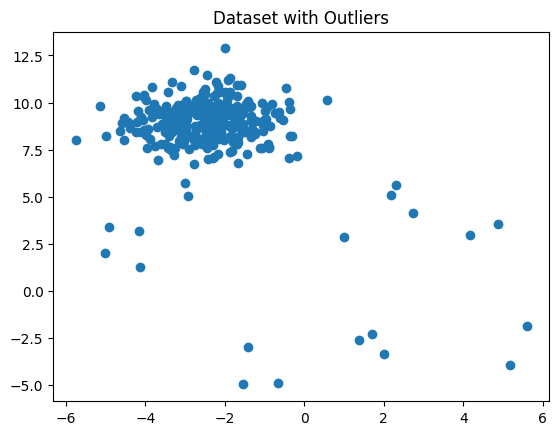

In [3]:
plt.scatter(X[:, 0], X[:, 1])
plt.title("Dataset with Outliers")
plt.show()

## ⚙️ Step 3: Apply LOF

- n_neighbors → number of neighbors (k)  
- contamination → expected anomaly proportion  

In [4]:
# Initialize model

model = LocalOutlierFactor(n_neighbors=20, contamination=0.05)

# Fit and predict
labels = model.fit_predict(X)

## 🔍 Step 4: Output Interpretation

- 1 → Normal  
- -1 → Anomaly  

In [5]:
# Create DataFrame

df = pd.DataFrame(X, columns=["Feature1", "Feature2"])
df["Anomaly"] = labels

df.head()

,Feature1,Feature2,Anomaly
0,-2.182270,8.795186,1
1,-1.761904,9.624656,1
2,-3.110904,10.866564,1
3,-2.395680,9.676417,1
4,-4.980842,8.217391,1


## 📊 Step 5: Visualize Anomalies

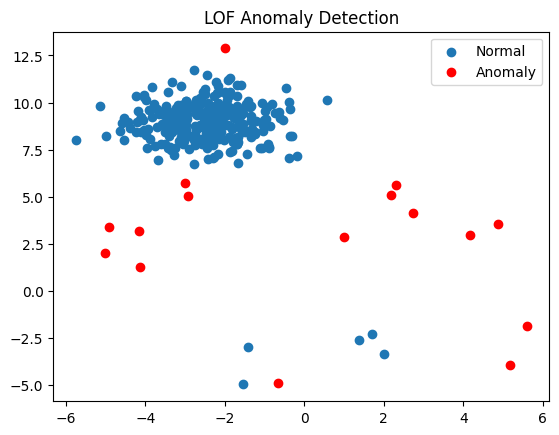

In [6]:
# Separate points

normal = df[df["Anomaly"] == 1]
anomaly = df[df["Anomaly"] == -1]

# Plot

plt.scatter(normal["Feature1"], normal["Feature2"], label="Normal")
plt.scatter(anomaly["Feature1"], anomaly["Feature2"], color='red', label="Anomaly")

plt.legend()
plt.title("LOF Anomaly Detection")
plt.show()

## ⚠️ Important Observations

- LOF compares **local density**  
- Works better when density varies  
- Sensitive to `n_neighbors`  

---

## 🎯 Key Takeaways

- Detects local anomalies  
- Uses neighbor-based approach  
- Different from Isolation Forest  

---

## 🧠 One-Line Summary

> LOF detects anomalies by comparing local density of a point with its neighbors.